In [ ]:
pip install -r requirements.txt

In [2]:
import numpy as np
import torch
from torchvision import transforms
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from file_loader import get_all_files

from data_utils import PreClassificationDataset, albumentation_transforms, compute_class_weights
from network.classification_net import PreClassificationModel
from solver import Solver

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

In [3]:
data = 'unlabelled_images_1'
files = get_all_files(data, 'png')
len(files)

17072

In [4]:
!python train_val_split.py                   # we use 'unlabelled_images_1' to train pre-classification model

### find mean and standard deviation of data (used for standardization)

In [ ]:

to_tensor = transforms.Compose([transforms.ToTensor()])
train_data = PreClassificationDataset(image_paths_file = 'train.txt', to_tensor_center = to_tensor, to_tensor_full = to_tensor)
train_loader = torch.utils.data.DataLoader(train_data,
                                          batch_size=5,
                                          shuffle=False,
                                          num_workers=1)
nimages = 0
mean = 0.0                    
var = 0.0
for (inputs,target) in train_loader: #Note: inputs must be tensor with values between (0,1) - to calculate mean and std
    batch = inputs
    # Rearrange batch to be the shape of [B, C, W * H]
    batch = batch.view(batch.size(0), batch.size(1), -1)
    nimages += batch.size(0)
    # Compute mean and std here
    mean += batch.mean(2).sum(0) 
    var += batch.var(2).sum(0)
mean /= nimages
var /= nimages
std = torch.sqrt(var)
print(mean)
print(std)
print(nimages)

Train size: 13657
Val size: 3415
Concatenated Img size:  torch.Size([6, 120, 120])


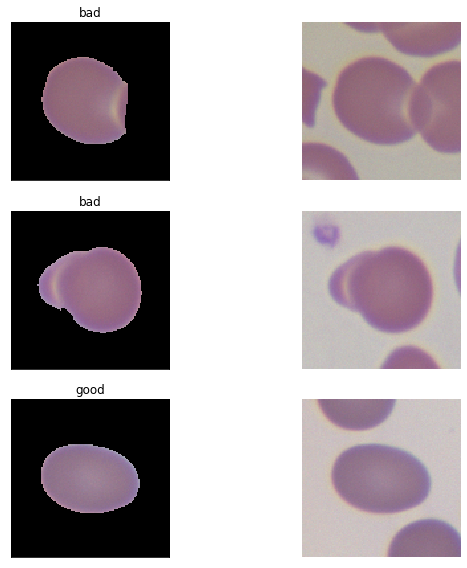

In [6]:

to_tensor_trainset_center = transforms.Compose([transforms.ToTensor(),
                               transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))])           
                               
to_tensor_trainset_full = transforms.Compose([transforms.ToTensor(),
                               transforms.Normalize((0.6854, 0.6160, 0.6519), (0.0793, 0.1305, 0.0789))])        

to_tensor_valset_center = transforms.Compose([transforms.ToTensor(),
                               transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))])         
                               
to_tensor_valset_full = transforms.Compose([transforms.ToTensor(),
                               transforms.Normalize((0.6844, 0.6154, 0.6511), (0.0803, 0.1312, 0.0791))])        

train_data = PreClassificationDataset(image_paths_file = 'train.txt',\
            to_tensor_center = to_tensor_trainset_center, to_tensor_full = to_tensor_trainset_full, aug_transforms = albumentation_transforms())

val_data = PreClassificationDataset(image_paths_file = 'val.txt',\
            to_tensor_center = to_tensor_valset_center, to_tensor_full = to_tensor_valset_full)

print("Train size: %i" % len(train_data))
print("Val size: %i" % len(val_data))
print("Concatenated Img size: ", train_data[0][0].size())

target_dict = {0: 'good', 1: 'bad'}
# visualization.
num_example_imgs = 3
for i, (img, target) in enumerate(train_data[0:num_example_imgs]):
    

    plt.subplot(num_example_imgs, 2, i * 2 + 1)

    # unnormalize                               
    img[0] = img[0]/2 + 0.5
    img[1] = img[1]/2 + 0.5
    img[2] = img[2]/2 + 0.5
    img_center = img[0:3]
    plt.imshow(img_center.numpy().transpose(1,2,0))
    plt.xticks([])
    plt.yticks([])
    plt.title(target_dict[target])
    
    plt.subplot(num_example_imgs, 2, i * 2 + 2)
    # unnormalize                              
    img[3] = img[3]*0.0793 + 0.6854
    img[4] = img[4]*0.1305 + 0.6160
    img[5] = img[5]*0.0789 + 0.6519
    img_full = img[3:6]
    plt.imshow(img_full.numpy().transpose(1,2,0))
    plt.axis('off')
plt.tight_layout()    
plt.show()

### Training

In [ ]:
train_dataloader = torch.utils.data.DataLoader(train_data, batch_size=16, num_workers=1, shuffle=True)
                        
val_dataloader = torch.utils.data.DataLoader(val_data, batch_size=4, num_workers=1)

model = PreClassificationModel(num_classes = 1)

weights = compute_class_weights(train_data)   # To encounter class imbalance

solver = Solver(weights)
                
solver.train(model, train_dataloader, val_dataloader, num_epochs=30)

In [ ]:
model.save("models/preclassification_epoch_30.model")

In [8]:
model = torch.load("models/preclassification_epoch_30.model")
model.to(device)

from torch.autograd import Variable
val_dataloader = torch.utils.data.DataLoader(val_data, batch_size=1, shuffle=False, num_workers=1)
predictions = []
gt = []
model.eval()
for (inputs,targets) in val_dataloader:
                
    inputs, targets = Variable(inputs), Variable(targets)
                
    inputs, targets = inputs.to(device), targets.to(device)
    outputs = model(inputs)
    
    pred = np.array(outputs.cpu() > 0.5, dtype=float)
    predictions.append(pred)
    
    gt.append((targets[0].data.cpu().numpy()))
model.train()
predictions = np.squeeze(np.array(predictions)) 
gt=np.array(gt)

### Performance on validation data

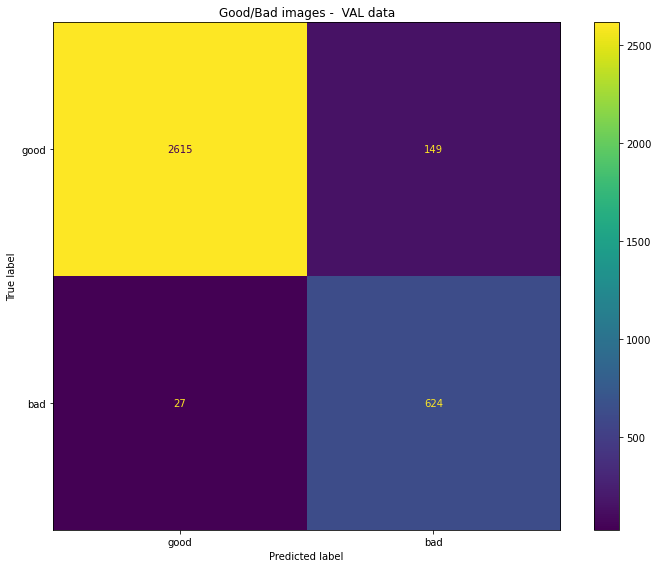

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cn_matrix = confusion_matrix(
        y_true=gt,
        y_pred=predictions
        )
plt.rcParams.update({'font.size': 10})
disp = ConfusionMatrixDisplay(confusion_matrix=cn_matrix, display_labels=['good','bad'])
disp.plot(xticks_rotation='horizontal')
plt.title("Good/Bad images -  VAL data")
plt.tight_layout()
plt.show() 